In [1]:
from pathlib import Path
import json
import time

import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from dataloader import create_dataloaders
from model import CharacterGPT, GPTConfig

C:\Users\samruddhi\anaconda3\envs\data266_lab\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Adding the device and project configuration:

In [2]:
# Project location
project_dir = Path(
    r"C:\Users\samruddhi\Desktop\Sam\Gen_AI_Lab1"
)

processed_dir = (
    project_dir
    / "task1_llm"
    / "Samruddhi"
    / "data_processed"
)

# Select GPU if available
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(
        f"GPU memory: "
        f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
    )

# Improve matrix multiplication performance on modern GPUs
torch.set_float32_matmul_precision("high")

Using device: cuda
GPU: NVIDIA GeForce RTX 5090
GPU memory: 34.19 GB


### Load the Vocabulary

In [3]:
vocab_file = processed_dir / "vocabulary.json"

with open(vocab_file, "r", encoding="utf-8") as file:
    vocabulary_data = json.load(file)

char_to_id = vocabulary_data["char_to_id"]
id_to_char = vocabulary_data["id_to_char"]

vocab_size = len(char_to_id)

print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 108


### Create the DataLoaders

In [4]:
# Create training and validation DataLoaders

block_size = 512
batch_size = 32

train_loader, val_loader = create_dataloaders(
    project_dir=project_dir,
    block_size=block_size,
    batch_size=batch_size
)

print("DataLoaders created successfully.")
print(f"Training batches per epoch: {len(train_loader):,}")
print(f"Validation batches: {len(val_loader):,}")

input_batch, target_batch = next(iter(train_loader))

print(f"Input batch shape: {input_batch.shape}")
print(f"Target batch shape: {target_batch.shape}")

DataLoaders created successfully.
Training batches per epoch: 5,365
Validation batches: 550
Input batch shape: torch.Size([32, 512])
Target batch shape: torch.Size([32, 512])


### Initialize the GPT Model

In [5]:
config = GPTConfig(
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=384,
    n_head=6,
    n_layer=6,
    dropout=0.1
)

model = CharacterGPT(config).to(device)

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Trainable parameters: {parameter_count:,}")
print(f"Model device: {next(model.parameters()).device}")

Trainable parameters: 10,927,104
Model device: cuda:0


### Configure the Optimizer and Training Settings

In [6]:
# Learning configuration
learning_rate = 3e-4
weight_decay = 0.01
num_epochs = 1000

# Evaluation configuration
eval_iters = 50

# Gradient clipping value
gradient_clip = 1.0

# Early stopping configuration
patience = 10
min_delta = 0.001

# Create the AdamW optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

# Store training results
train_losses = []
val_losses = []

# Track the best validation loss
best_val_loss = float("inf")
epochs_without_improvement = 0

# Directory for model checkpoints
checkpoint_dir = (
    project_dir
    / "task1_llm"
    / "Samruddhi"
    / "checkpoints"
)

checkpoint_dir.mkdir(
    parents=True,
    exist_ok=True
)

best_model_path = (
    checkpoint_dir
    / "best_model.pt"
)

print("Training configuration created.")
print(f"Learning rate: {learning_rate}")
print(f"Maximum epochs: {num_epochs:,}")
print(f"Evaluation batches: {eval_iters}")
print(f"Early stopping patience: {patience}")
print(f"Minimum improvement required: {min_delta}")
print(f"Checkpoint directory: {checkpoint_dir}")

Training configuration created.
Learning rate: 0.0003
Maximum epochs: 1,000
Evaluation batches: 50
Early stopping patience: 10
Minimum improvement required: 0.001
Checkpoint directory: C:\Users\samruddhi\Desktop\Sam\Gen_AI_Lab1\task1_llm\Samruddhi\checkpoints


### Create the Loss Evaluation Function

In [7]:
@torch.no_grad()
def estimate_loss(data_loader):
    """
    Estimate the average loss for a DataLoader.
    """

    model.eval()

    losses = []
    data_iterator = iter(data_loader)

    number_of_batches = min(
        eval_iters,
        len(data_loader)
    )

    for _ in range(number_of_batches):
        input_batch, target_batch = next(
            data_iterator
        )

        input_batch = input_batch.to(
            device,
            non_blocking=True
        )

        target_batch = target_batch.to(
            device,
            non_blocking=True
        )

        # Use BF16 automatically on the GPU
        use_mixed_precision = device.type == "cuda"

        with torch.autocast(
            device_type=device.type,
            dtype=torch.bfloat16,
            enabled=use_mixed_precision
        ):
            _, loss = model(
                input_batch,
                target_batch
            )

        losses.append(loss.item())

    model.train()

    return sum(losses) / len(losses)

### Train the GPT Model

In [8]:
# Start training with epochs and early stopping

model.train()

# Reset tracking values
train_losses.clear()
val_losses.clear()

best_val_loss = float("inf")
epochs_without_improvement = 0

training_start_time = time.time()

for epoch in range(num_epochs):

    model.train()
    total_training_loss = 0.0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{num_epochs}"
    )

    for input_batch, target_batch in progress_bar:

        # Move data to the GPU
        input_batch = input_batch.to(
            device,
            non_blocking=True
        )

        target_batch = target_batch.to(
            device,
            non_blocking=True
        )

        # Clear previous gradients
        optimizer.zero_grad(
            set_to_none=True
        )

        # Use BF16 mixed precision on the GPU
        use_mixed_precision = device.type == "cuda"

        with torch.autocast(
            device_type=device.type,
            dtype=torch.bfloat16,
            enabled=use_mixed_precision
        ):
            _, loss = model(
                input_batch,
                target_batch
            )

        # Compute gradients
        loss.backward()

        # Prevent excessively large gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            gradient_clip
        )

        # Update model weights
        optimizer.step()

        # Add batch loss to the epoch loss
        total_training_loss += loss.item()

        # Show live batch loss
        progress_bar.set_postfix(
            batch_loss=f"{loss.item():.4f}"
        )

    # Calculate average training loss for this epoch
    average_train_loss = (
        total_training_loss / len(train_loader)
    )

    # Calculate validation loss after the epoch
    average_val_loss = estimate_loss(
        val_loader
    )

    train_losses.append(average_train_loss)
    val_losses.append(average_val_loss)

    elapsed_minutes = (
        time.time() - training_start_time
    ) / 60

    print(
        f"\nEpoch {epoch + 1}/{num_epochs} completed"
    )
    print(
        f"Training loss: {average_train_loss:.4f}"
    )
    print(
        f"Validation loss: {average_val_loss:.4f}"
    )
    print(
        f"Elapsed time: {elapsed_minutes:.2f} minutes"
    )

    # Check whether validation loss improved
    if average_val_loss < best_val_loss - min_delta:

        best_val_loss = average_val_loss
        epochs_without_improvement = 0

        # Save the best model
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": average_train_loss,
                "val_loss": average_val_loss,
                "config": config.__dict__
            },
            best_model_path
        )

        print("Validation loss improved.")
        print(
            f"Best model saved to: {best_model_path}"
        )

    else:

        epochs_without_improvement += 1

        print(
            "Validation loss did not improve."
        )
        print(
            f"Early-stopping counter: "
            f"{epochs_without_improvement}/{patience}"
        )

    print("-" * 60)

    # Stop if validation loss does not improve
    # for the specified patience
    if epochs_without_improvement >= patience:

        print(
            f"Early stopping triggered after "
            f"{epoch + 1} epochs."
        )
        print(
            f"Best validation loss: {best_val_loss:.4f}"
        )
        break

print("Training completed.")

Epoch 1/1000: 100%|██████████| 5365/5365 [03:44<00:00, 23.95it/s, batch_loss=0.7136]



Epoch 1/1000 completed
Training loss: 1.0176
Validation loss: 0.7273
Elapsed time: 3.74 minutes
Validation loss improved.
Best model saved to: C:\Users\samruddhi\Desktop\Sam\Gen_AI_Lab1\task1_llm\Samruddhi\checkpoints\best_model.pt
------------------------------------------------------------


Epoch 2/1000: 100%|██████████| 5365/5365 [03:37<00:00, 24.63it/s, batch_loss=0.6720]



Epoch 2/1000 completed
Training loss: 0.6833
Validation loss: 0.6647
Elapsed time: 7.39 minutes
Validation loss improved.
Best model saved to: C:\Users\samruddhi\Desktop\Sam\Gen_AI_Lab1\task1_llm\Samruddhi\checkpoints\best_model.pt
------------------------------------------------------------


Epoch 3/1000: 100%|██████████| 5365/5365 [03:41<00:00, 24.21it/s, batch_loss=0.6135]


...


Epoch 20/1000 completed
Training loss: 0.5123
Validation loss: 0.5513
Elapsed time: 74.28 minutes
Validation loss improved.
Best model saved to: C:\Users\samruddhi\Desktop\Sam\Gen_AI_Lab1\task1_llm\Samruddhi\checkpoints\best_model.pt
------------------------------------------------------------


Epoch 21/1000: 100%|██████████| 5365/5365 [03:42<00:00, 24.07it/s, batch_loss=0.5013]



Epoch 21/1000 completed
Training loss: 0.5102
Validation loss: 0.5496
Elapsed time: 78.01 minutes
Validation loss improved.
Best model saved to: C:\Users\samruddhi\Desktop\Sam\Gen_AI_Lab1\task1_llm\Samruddhi\checkpoints\best_model.pt
------------------------------------------------------------


Epoch 22/1000:   1%|          | 55/5365 [00:02<03:46, 23.48it/s, batch_loss=0.5204]


KeyboardInterrupt: 

In [9]:
# Save the current model state
current_checkpoint_path = (
    checkpoint_dir / "model_after_21_epochs.pt"
)

torch.save(
    {
        "epoch": 21,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_losses": train_losses,
        "val_losses": val_losses,
        "config": config.__dict__,
    },
    current_checkpoint_path
)

print(f"Checkpoint saved to: {current_checkpoint_path}")

Checkpoint saved to: C:\Users\samruddhi\Desktop\Sam\Gen_AI_Lab1\task1_llm\Samruddhi\checkpoints\model_after_21_epochs.pt


### Load Best Trained Model

In [10]:
# Load the best checkpoint

best_model_path = checkpoint_dir / "best_model.pt"

if not best_model_path.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: {best_model_path}"
    )

checkpoint = torch.load(
    best_model_path,
    map_location=device,
    weights_only=False
)

# Handle either a complete checkpoint dictionary
# or a plain model state dictionary
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    saved_epoch = checkpoint.get(
        "epoch",
        "unknown"
    )

else:
    model.load_state_dict(checkpoint)
    saved_epoch = "unknown"

model.to(device)
model.eval()

print("Best model loaded successfully.")
print(f"Checkpoint: {best_model_path}")
print(f"Saved epoch: {saved_epoch}")

Best model loaded successfully.
Checkpoint: C:\Users\samruddhi\Desktop\Sam\Gen_AI_Lab1\task1_llm\Samruddhi\checkpoints\best_model.pt
Saved epoch: 21


### Evaluate Best Model Loss

In [11]:
# Evaluate the best trained model

best_train_loss = estimate_loss(train_loader)
best_val_loss = estimate_loss(val_loader)

best_train_perplexity = torch.exp(
    torch.tensor(best_train_loss)
).item()

best_val_perplexity = torch.exp(
    torch.tensor(best_val_loss)
).item()

print("BEST MODEL EVALUATION")
print("=" * 50)
print(f"Training cross-entropy loss:   {best_train_loss:.4f}")
print(f"Validation cross-entropy loss: {best_val_loss:.4f}")
print(f"Training perplexity:           {best_train_perplexity:.4f}")
print(f"Validation perplexity:         {best_val_perplexity:.4f}")
print(
    f"Generalization gap:            "
    f"{best_val_loss - best_train_loss:.4f}"
)

BEST MODEL EVALUATION
Training cross-entropy loss:   0.4805
Validation cross-entropy loss: 0.5496
Training perplexity:           1.6169
Validation perplexity:         1.7326
Generalization gap:            0.0691


### Plot Training and Validation Loss Curves

Output directory: C:\Users\samruddhi\Desktop\Sam\Gen_AI_Lab1\task1_llm\Samruddhi\outputs


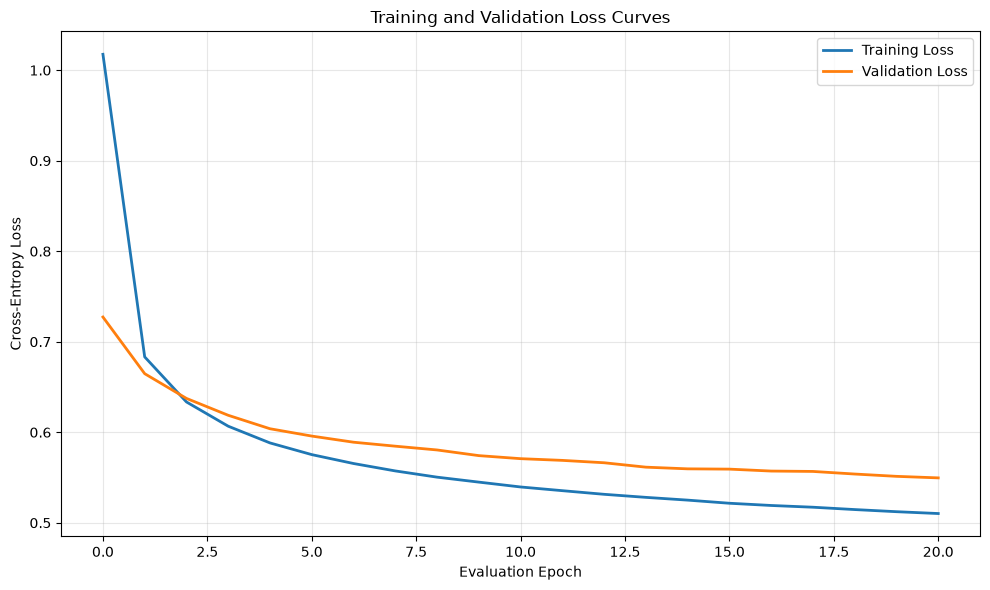

In [15]:
# Plot loss curves

from pathlib import Path

outputs_dir = (
    project_dir
    / "task1_llm"
    / "Samruddhi"
    / "outputs"
)

outputs_dir.mkdir(
    parents=True,
    exist_ok=True
)

print(f"Output directory: {outputs_dir}")

plt.figure(figsize=(10, 6))

plt.plot(
    train_losses,
    label="Training Loss",
    linewidth=2
)

plt.plot(
    val_losses,
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Evaluation Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training and Validation Loss Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

loss_plot_path = (
    outputs_dir / "training_validation_loss_curves.png"
)

plt.savefig(
    loss_plot_path,
    dpi=150
)

plt.show()

The training and validation losses decreased during the initial epochs and then became nearly flat. This indicates that the model reached a learning plateau, meaning that additional training produced little improvement. The validation loss followed a similar trend to the training loss, so there is no strong evidence of severe overfitting. Therefore, stopping the training after 21 epochs was reasonable because continuing toward 1,000 epochs would likely provide limited additional benefit.

### Generate Text Using Temperature Sampling

In [17]:
# Define the unknown-character token
UNK_TOKEN = "<UNK>"

print(f"Unknown token: {UNK_TOKEN}")
print(f"Unknown token ID: {char_to_id[UNK_TOKEN]}")

Unknown token: <UNK>
Unknown token ID: 0


In [18]:
# Generate text using the trained model

model.eval()

def decode_token_ids(token_ids):
    return "".join(
        id_to_char[str(int(token_id))]
        for token_id in token_ids
    )


prompt = "Once upon a time"

prompt_ids = [
    char_to_id.get(
        character,
        char_to_id[UNK_TOKEN]
    )
    for character in prompt
]

input_ids = torch.tensor(
    [prompt_ids],
    dtype=torch.long,
    device=device
)

generated_ids = model.generate(
    input_ids=input_ids,
    max_new_tokens=300,
    temperature=0.8
)

generated_text = decode_token_ids(
    generated_ids[0].cpu().tolist()
)

print(generated_text)

generated_text_path = (
    outputs_dir / "generated_sample_temperature_0_8.txt"
)

with open(
    generated_text_path,
    "w",
    encoding="utf-8"
) as file:
    file.write(generated_text)

print(f"\nGenerated text saved to: {generated_text_path}")

Once upon a time, there was a little boy named Timmy. He loved to write with his jewels. He would spread them on the paper every day. One day, Timmy wrote a letter to his friend, Timmy. Timmy asked, "What kind of person do you write letters?" Timmy replied, "I write how fast I can write letters and stories." Timmy 

Generated text saved to: C:\Users\samruddhi\Desktop\Sam\Gen_AI_Lab1\task1_llm\Samruddhi\outputs\generated_sample_temperature_0_8.txt


The model generated mostly readable story-like text and learned basic grammar, punctuation, dialogue, and narrative structure. However, it produced repetition and occasional semantically incorrect phrases. These failures indicate that the model learned local character and word patterns but did not fully learn long-range story coherence.

### Document Generated Text Failure Analysis

In [19]:
# Create Task 1 failure analysis

failure_analysis_path = (
    project_dir
    / "task1_llm"
    / "Samruddhi"
    / "failure_analysis.md"
)

failure_analysis = """
# Task 1 : Sequence Model Failure Analysis

## Failure Case 1: Repetition

### Generated snippet

> One day, Timmy wrote a letter to his friend, Timmy. Timmy asked, "What kind of person do you write letters?" Timmy replied...

### Failure type

Repetition

### Observation

The model repeatedly generated the name “Timmy.” This indicates that the model learned the name as a common local pattern but could not maintain enough long-range context to introduce different characters or ideas.

---

## Failure Case 2: Semantically Incorrect Phrase

### Generated snippet

> He loved to write with his jewels.

### Failure type

Semantic inconsistency

### Observation

The sentence is grammatically understandable, but “write with his jewels” is unusual and does not fit the context. The model produced a locally plausible sequence of words but did not fully understand the meaning of the sentence.

---

## Failure Case 3: Loss of Coherence

### Generated snippet

> Timmy asked, "What kind of person do you write letters?" Timmy replied, "I write how fast I can write letters and stories." Timmy

### Failure type

Loss of coherence and incomplete ending

### Observation

The dialogue becomes unnatural and the generated story ends abruptly. The model appears to predict short-range character patterns correctly but struggles to maintain a logical conversation and complete the story.
"""

with open(
    failure_analysis_path,
    "w",
    encoding="utf-8"
) as file:
    file.write(failure_analysis)

print(
    f"Failure analysis saved to: "
    f"{failure_analysis_path}"
)

Failure analysis saved to: C:\Users\samruddhi\Desktop\Sam\Gen_AI_Lab1\task1_llm\Samruddhi\failure_analysis.md


### Calculate Core Evaluation Metrics

In [20]:
import csv
import math

# Calculate core metrics

validation_perplexity = math.exp(best_val_loss)

validation_bits_per_character = (
    best_val_loss / math.log(2)
)

generalization_gap = (
    best_val_loss - best_train_loss
)

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

core_metrics = {
    "training_cross_entropy_loss": best_train_loss,
    "validation_cross_entropy_loss": best_val_loss,
    "training_perplexity": math.exp(best_train_loss),
    "validation_perplexity": validation_perplexity,
    "validation_bits_per_character": validation_bits_per_character,
    "generalization_gap": generalization_gap,
    "parameter_count": parameter_count
}

metrics_path = (
    project_dir
    / "task1_llm"
    / "Samruddhi"
    / "metrics_report.csv"
)

with open(
    metrics_path,
    "w",
    newline="",
    encoding="utf-8"
) as file:

    writer = csv.writer(file)

    writer.writerow(
        ["metric", "value"]
    )

    for metric_name, metric_value in core_metrics.items():
        writer.writerow(
            [metric_name, metric_value]
        )

print("Core metrics calculated:")
for metric_name, metric_value in core_metrics.items():
    print(f"{metric_name}: {metric_value}")

print(f"\nMetrics saved to: {metrics_path}")

Core metrics calculated:
training_cross_entropy_loss: 0.4804840487241745
validation_cross_entropy_loss: 0.5496274960041047
training_perplexity: 1.6168568503016727
validation_perplexity: 1.7326074944298362
validation_bits_per_character: 0.7929448628213404
generalization_gap: 0.06914344727993016
parameter_count: 10927104

Metrics saved to: C:\Users\samruddhi\Desktop\Sam\Gen_AI_Lab1\task1_llm\Samruddhi\metrics_report.csv


### Calculate Top-1 Next-Character Accuracy

In [21]:
@torch.no_grad()
def estimate_top1_accuracy(data_loader):
    """
    Calculate the percentage of positions where the model's
    highest-probability character matches the target character.
    """

    model.eval()

    correct_characters = 0
    total_characters = 0

    for batch_index, (input_batch, target_batch) in enumerate(
        data_loader
    ):

        if batch_index >= eval_iters:
            break

        input_batch = input_batch.to(
            device,
            non_blocking=True
        )

        target_batch = target_batch.to(
            device,
            non_blocking=True
        )

        use_mixed_precision = device.type == "cuda"

        with torch.autocast(
            device_type=device.type,
            dtype=torch.bfloat16,
            enabled=use_mixed_precision
        ):

            logits, _ = model(input_batch)

        predictions = torch.argmax(
            logits,
            dim=-1
        )

        correct_characters += (
            (predictions == target_batch)
            .sum()
            .item()
        )

        total_characters += target_batch.numel()

    model.train()

    return correct_characters / total_characters


train_top1_accuracy = estimate_top1_accuracy(
    train_loader
)

val_top1_accuracy = estimate_top1_accuracy(
    val_loader
)

print(
    f"Training top-1 accuracy: "
    f"{train_top1_accuracy * 100:.2f}%"
)

print(
    f"Validation top-1 accuracy: "
    f"{val_top1_accuracy * 100:.2f}%"
)

Training top-1 accuracy: 84.52%
Validation top-1 accuracy: 82.62%


The model achieved a training top-1 next-character accuracy of 84.52% and a validation accuracy of 82.62%. The generalization gap was only 1.90 percentage points, indicating that the model performs similarly on unseen validation data and does not show severe overfitting. Although the accuracy is strong, it should be considered alongside the generated text because frequent characters are easier to predict than less common characters.

### Save Top-1 Accuracy Metrics

In [22]:
# Append top-1 accuracy metrics to the report

with open(
    metrics_path,
    "a",
    newline="",
    encoding="utf-8"
) as file:

    writer = csv.writer(file)

    writer.writerow(
        [
            "training_top1_next_character_accuracy",
            train_top1_accuracy
        ]
    )

    writer.writerow(
        [
            "validation_top1_next_character_accuracy",
            val_top1_accuracy
        ]
    )

print("Top-1 accuracy metrics added to metrics_report.csv.")

Top-1 accuracy metrics added to metrics_report.csv.


### Calculate Generation Diversity Metrics

In [23]:
def get_ngrams(text, n):
    """
    Return all character n-grams from the generated text.
    """

    return [
        text[index:index + n]
        for index in range(len(text) - n + 1)
    ]


def distinct_n(text, n):
    """
    Distinct-n = unique n-grams / total n-grams.
    """

    ngrams = get_ngrams(text, n)

    if len(ngrams) == 0:
        return 0.0

    return len(set(ngrams)) / len(ngrams)


def repeated_ngram_rate(text, n):
    """
    Repeated n-gram rate =
    repeated n-gram occurrences / total n-gram occurrences.
    """

    ngrams = get_ngrams(text, n)

    if len(ngrams) == 0:
        return 0.0

    unique_ngrams = len(set(ngrams))
    repeated_occurrences = len(ngrams) - unique_ngrams

    return repeated_occurrences / len(ngrams)


distinct_1 = distinct_n(generated_text, 1)
distinct_2 = distinct_n(generated_text, 2)
distinct_3 = distinct_n(generated_text, 3)
repeated_4gram = repeated_ngram_rate(
    generated_text,
    4
)

print(f"Distinct-1: {distinct_1:.4f}")
print(f"Distinct-2: {distinct_2:.4f}")
print(f"Distinct-3: {distinct_3:.4f}")
print(f"Repeated 4-gram rate: {repeated_4gram:.4f}")

Distinct-1: 0.1013
Distinct-2: 0.4508
Distinct-3: 0.7070
Repeated 4-gram rate: 0.1789


- The generated text had a Distinct-1 score of **0.1013**, a Distinct-2 score of **0.4508**, and a Distinct-3 score of **0.7070**.
- The high Distinct-3 score shows that the model created many different three-character patterns.
- The repeated 4-gram rate was **17.89%**, meaning the model repeated some character patterns and phrases.
- This matches the repeated use of **“Timmy”** in the generated story.

### Save Diversity Metrics

In [24]:
# Append diversity metrics to the report

with open(
    metrics_path,
    "a",
    newline="",
    encoding="utf-8"
) as file:

    writer = csv.writer(file)

    writer.writerow(
        ["distinct_1", distinct_1]
    )

    writer.writerow(
        ["distinct_2", distinct_2]
    )

    writer.writerow(
        ["distinct_3", distinct_3]
    )

    writer.writerow(
        ["repeated_4gram_rate", repeated_4gram]
    )

print("Diversity metrics added to metrics_report.csv.")

Diversity metrics added to metrics_report.csv.


### Check Training Stability and Gradient Norm

In [25]:
import math

# Check for invalid loss values

all_recorded_losses = (
    train_losses + val_losses
)

contains_nan = any(
    not math.isfinite(loss)
    for loss in all_recorded_losses
)

loss_spike_count = 0

for index in range(1, len(train_losses)):
    previous_loss = train_losses[index - 1]
    current_loss = train_losses[index]

    if current_loss > previous_loss * 1.5:
        loss_spike_count += 1


# Calculate a gradient norm using one training batch

model.train()

input_batch, target_batch = next(
    iter(train_loader)
)

input_batch = input_batch.to(
    device,
    non_blocking=True
)

target_batch = target_batch.to(
    device,
    non_blocking=True
)

optimizer.zero_grad(
    set_to_none=True
)

use_mixed_precision = device.type == "cuda"

with torch.autocast(
    device_type=device.type,
    dtype=torch.bfloat16,
    enabled=use_mixed_precision
):

    _, stability_loss = model(
        input_batch,
        target_batch
    )

stability_loss.backward()

gradient_norm = torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    max_norm=float("inf")
).item()

optimizer.zero_grad(
    set_to_none=True
)

model.eval()

print(f"Gradient norm: {gradient_norm:.4f}")
print(f"NaN or infinite losses found: {contains_nan}")
print(f"Training loss spikes found: {loss_spike_count}")

Gradient norm: 0.1551
NaN or infinite losses found: False
Training loss spikes found: 0


- **Gradient norm 0.1551:** The model’s weight updates were small and controlled. The model was not making unstable, extremely large changes.
- **No NaN or infinite losses:** The calculations remained valid. The training did not break mathematically.
- **No loss spikes:** The error did not suddenly jump to a very large value.
- **Numerically stable:** The training behaved normally without exploding or becoming invalid.

### Save Training Stability Metrics

In [26]:
# Append training stability metrics

with open(
    metrics_path,
    "a",
    newline="",
    encoding="utf-8"
) as file:

    writer = csv.writer(file)

    writer.writerow(
        ["gradient_norm", gradient_norm]
    )

    writer.writerow(
        ["contains_nan_or_infinite_loss", contains_nan]
    )

    writer.writerow(
        ["training_loss_spike_count", loss_spike_count]
    )

print("Training stability metrics added to metrics_report.csv.")

Training stability metrics added to metrics_report.csv.


### Measure Text Generation Performance and GPU Memory

In [27]:
import time

model.eval()

if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats(device)

generation_start_time = time.perf_counter()

with torch.no_grad():
    timed_generated_ids = model.generate(
        input_ids=input_ids,
        max_new_tokens=100,
        temperature=0.8
    )

if device.type == "cuda":
    torch.cuda.synchronize(device)

generation_end_time = time.perf_counter()

generation_time_seconds = (
    generation_end_time - generation_start_time
)

generated_token_count = (
    timed_generated_ids.shape[1]
    - input_ids.shape[1]
)

generation_tokens_per_second = (
    generated_token_count
    / generation_time_seconds
)

if device.type == "cuda":
    peak_memory_bytes = torch.cuda.max_memory_allocated(
        device
    )

    peak_memory_gb = (
        peak_memory_bytes / (1024 ** 3)
    )
else:
    peak_memory_gb = 0.0

print(
    f"Generation tokens: {generated_token_count}"
)

print(
    f"Generation time: "
    f"{generation_time_seconds:.4f} seconds"
)

print(
    f"Generation speed: "
    f"{generation_tokens_per_second:.2f} tokens/second"
)

print(
    f"Peak memory during generation: "
    f"{peak_memory_gb:.4f} GB"
)

Generation tokens: 100
Generation time: 0.3730 seconds
Generation speed: 268.09 tokens/second
Peak memory during generation: 0.2814 GB


- The model generated **100 new characters**.
- It took **0.373 seconds** to generate 100 new characters
- The model generated about **268 characters per second**.
- In this model, one token represents one character.
- The model used about **0.28 GB of GPU memory** during generation.

### Save Text Generation Performance Metrics

In [28]:
# Append generation performance metrics

with open(
    metrics_path,
    "a",
    newline="",
    encoding="utf-8"
) as file:

    writer = csv.writer(file)

    writer.writerow(
        [
            "generation_tokens_per_second",
            generation_tokens_per_second
        ]
    )

    writer.writerow(
        [
            "generation_time_seconds",
            generation_time_seconds
        ]
    )

    writer.writerow(
        [
            "generation_peak_memory_gb",
            peak_memory_gb
        ]
    )

print(
    "Generation performance metrics added "
    "to metrics_report.csv."
)

Generation performance metrics added to metrics_report.csv.


### Total number of parameters trained

In [29]:
# Count model parameters

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")

Total parameters: 10,927,104
Trainable parameters: 10,927,104


### Display Complete Model Architecture and Parameters

In [30]:
# Print the complete model architecture

print(model)

print("\nPARAMETER DETAILS")
print("=" * 80)

total_parameters = 0
trainable_parameters = 0

for parameter_name, parameter in model.named_parameters():

    parameter_count = parameter.numel()
    total_parameters += parameter_count

    if parameter.requires_grad:
        trainable_parameters += parameter_count

    print(
        f"{parameter_name:<60}"
        f"Shape: {str(tuple(parameter.shape)):<20}"
        f"Parameters: {parameter_count:,}"
    )

print("\nPARAMETER SUMMARY")
print("=" * 80)
print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")
print(
    f"Non-trainable parameters: "
    f"{total_parameters - trainable_parameters:,}"
)

CharacterGPT(
  (token_embedding): Embedding(108, 384)
  (position_embedding): Embedding(512, 384)
  (embedding_dropout): Dropout(p=0.1, inplace=False)
  (transformer_blocks): ModuleList(
    (0-5): 6 x TransformerBlock(
      (layer_norm_1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (attention): CausalSelfAttention(
        (qkv_projection): Linear(in_features=384, out_features=1152, bias=True)
        (output_projection): Linear(in_features=384, out_features=384, bias=True)
        (attention_dropout): Dropout(p=0.1, inplace=False)
        (residual_dropout): Dropout(p=0.1, inplace=False)
      )
      (layer_norm_2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (feed_forward): FeedForward(
        (network): Sequential(
          (0): Linear(in_features=384, out_features=1536, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=1536, out_features=384, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
 